In [1]:
## Imports

import pandas as pd
import numpy as np
import datetime as dt

import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')


Purpose of Notebook

This notebook combines features engineering work from Spencer and Phuc into a unified weekly feature dataset.
The engineered features serve two related but distinct purposes:

1) regime detection via unsupervised learning
2) next regime prediction via supervised learning

Because these tasks benefit from somewhat different feature constructions, both sets are built here and merged into a final export.

In [2]:
combine_unclean_df = pd.read_parquet("combined_weekly_dataset.parquet")

In [3]:
df = combine_unclean_df.copy()

# dates already in index
df.index = pd.to_datetime(df.index, errors="coerce")
df = df[~df.index.isna()].copy()
df = df.sort_index()

# remove duplicate columns / dates
df = df.loc[:, ~df.columns.duplicated()].copy()
df = df[~df.index.duplicated(keep="first")].copy()

price_cols = [
    "SP500_SPY",
    "NASDAQ100_QQQ",
    "DOW_JONES",
    "NASDAQ100",
    "NIKKEI_225",
    "SHANGHAI_COMPOSITE",
    "HANG_SENG",
    "TREASURY_BOND_TLT",
    "GOLD_GLD",
    "usd_index"
]

# weekly log returns
log_returns = np.log(df[price_cols] / df[price_cols].shift(1))
log_returns = log_returns.dropna(how="all")

# rolling vol
volatility_4w = log_returns.rolling(window=4, min_periods=4).std()
volatility_12w = log_returns.rolling(window=12, min_periods=12).std()

# vol of vol
vov_4w = volatility_4w.rolling(window=4, min_periods=4).std()
vov_12w = volatility_12w.rolling(window=12, min_periods=12).std()

# aggregate regime features
global_vol_4w = volatility_4w.mean(axis=1)
global_vol_12w = volatility_12w.mean(axis=1)
vol_slope = global_vol_4w - global_vol_12w
global_vov_12w = vov_12w.mean(axis=1)

# macro features
yield_curve = df["TREASURY_10Y"] - df["TREASURY_2Y"]
vix_levels = df["VIX"]

# final feature set
features = pd.DataFrame({
    "global_vol": global_vol_12w,
    "vol_slope": vol_slope,
    "vov": global_vov_12w,
    "yield_slope": yield_curve,
    "vix": vix_levels
}, index=df.index)

features = pd.concat([features, log_returns.add_suffix("_ret")], axis=1)
features = features.dropna()

In [4]:
# Builds return, volatility, momentum, VIX, and yield spread features
#Pick variables used to detect regimes
#Find returns for major assets
#Find market volatility
#Find momentum
#Find VIX changes
#Find yield spread (10Y − 2Y)
#Create final feature dataset for clustering
#Exclude TLT and GLD so the clustering sample starts earlier

combine2 = pd.read_parquet("/work/data_prep.parquet")

rdf2 = combine2[["SPY", "QQQ", "VIX", "10_Year_Treasury_Yield", "2_Year_Treasury_Yield"]].copy()
rdf2 = rdf2.rename(columns={"10_Year_Treasury_Yield": "TREASURY_10Y","2_Year_Treasury_Yield": "TREASURY_2Y"})
rdf2["SPY_return"] = rdf2["SPY"].pct_change()
rdf2["QQQ_return"] = rdf2["QQQ"].pct_change()
rdf2["SPY_vol_12"] = rdf2["SPY_return"].rolling(12).std()
rdf2["SPY_vol_4"] = rdf2["SPY_return"].rolling(4).std()
rdf2["SPY_momentum_12"] = rdf2["SPY"].pct_change(12)
rdf2["VIX_change"] = rdf2["VIX"].pct_change()
rdf2["yield_spread"] = rdf2["TREASURY_10Y"] - rdf2["TREASURY_2Y"]
fcol2 = ["SPY_return","QQQ_return","SPY_vol_12","SPY_vol_4","SPY_momentum_12","VIX","VIX_change","TREASURY_10Y",
        "TREASURY_2Y", "yield_spread"]

kmf2 = rdf2[fcol2].dropna().copy()

kmf2.to_parquet("reg_feat2.parquet")
rdf2.to_parquet("reg_base2.parquet")

In [5]:
merged_features = features.join(kmf2, how = 'inner')
merged_features = merged_features.drop(columns=["vix", "yield_slope"], errors="ignore")

merged_features.index = pd.to_datetime(merged_features.index)
merged_features = merged_features.sort_index()
merged_features.index.name = "date"

In [6]:
merged_features.to_csv("Features_volatility.csv")

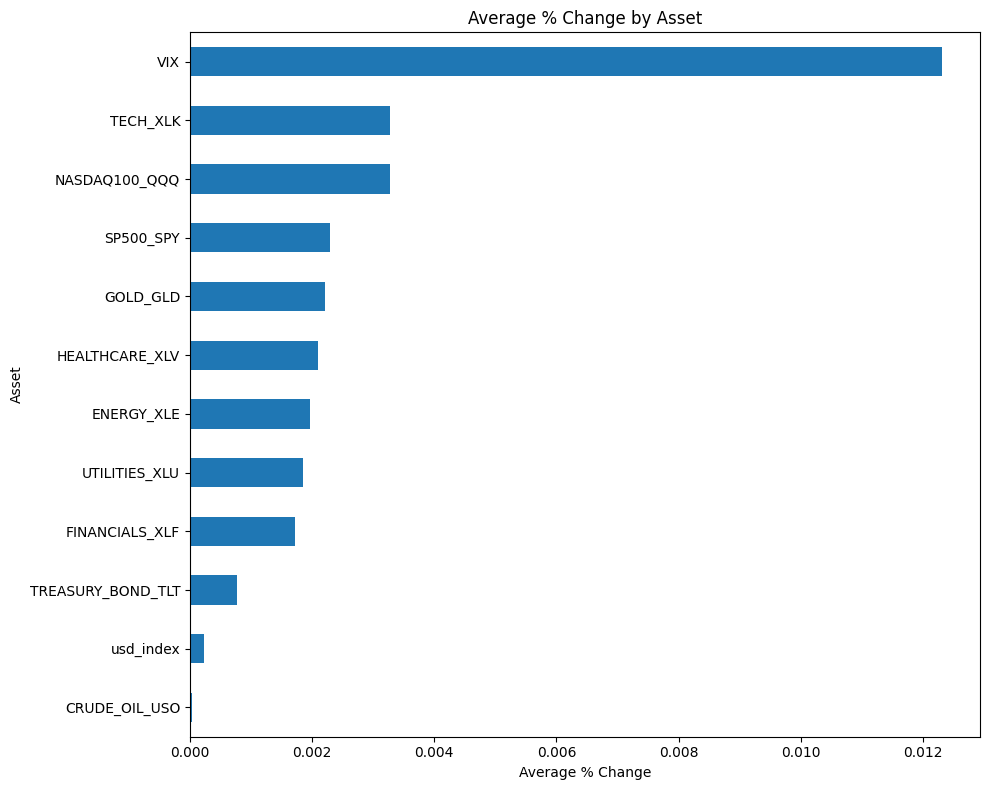

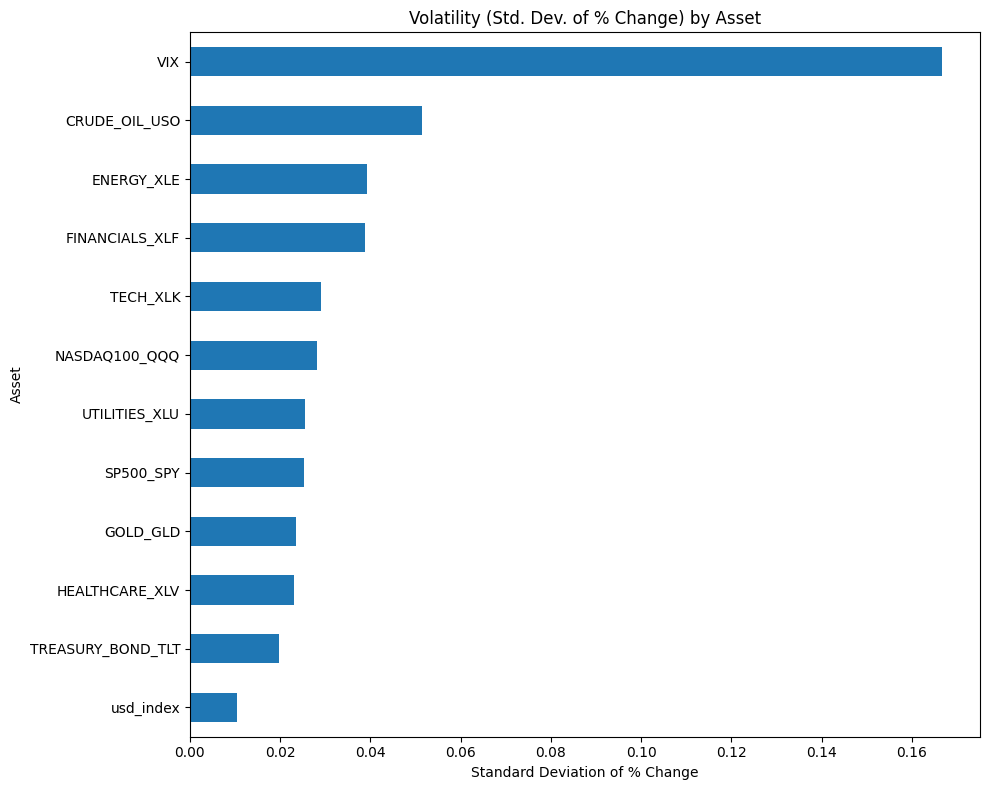

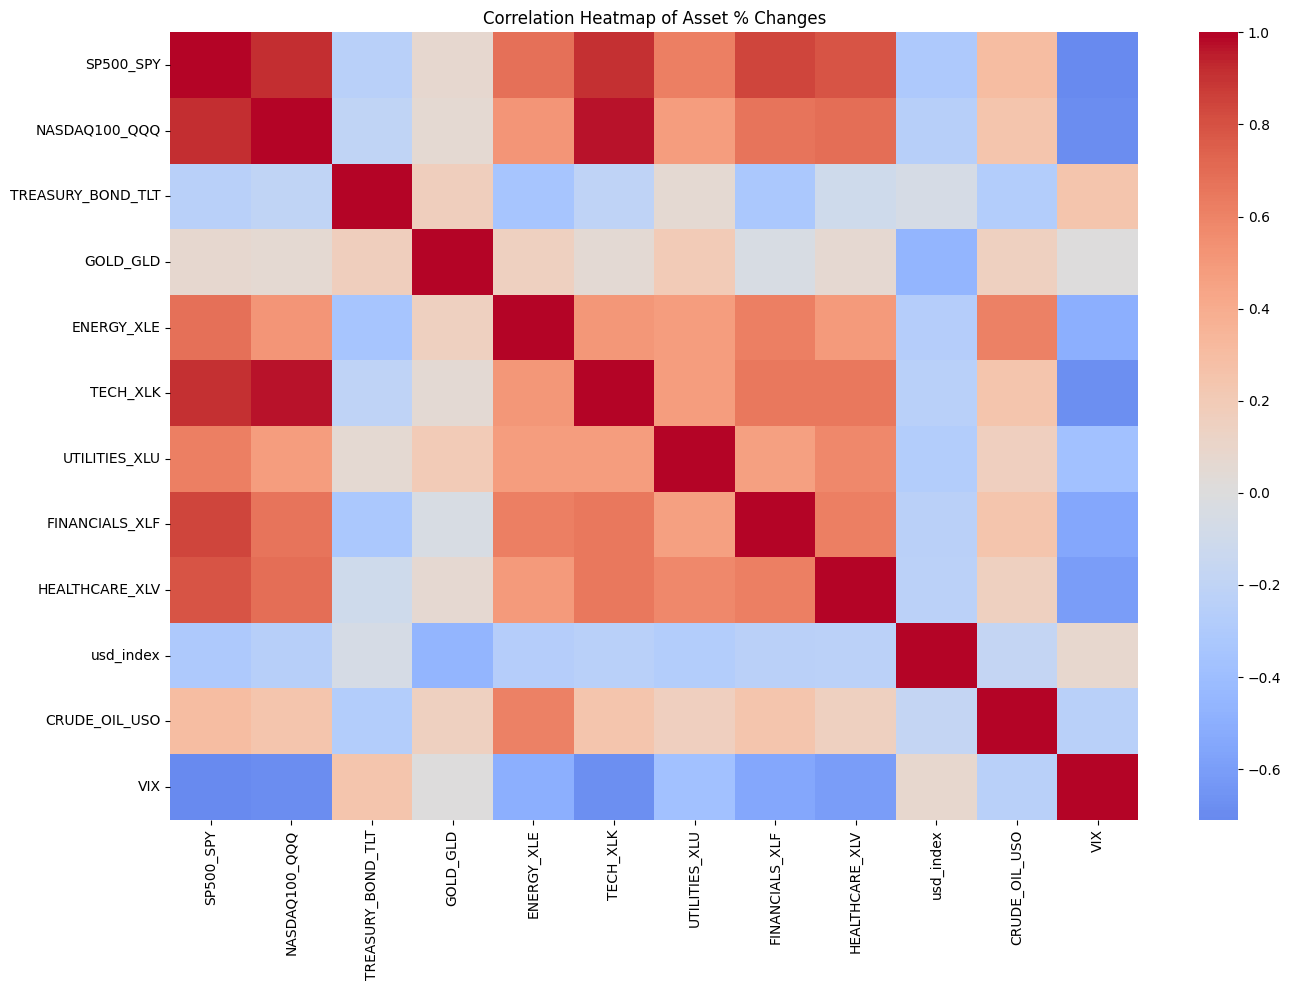

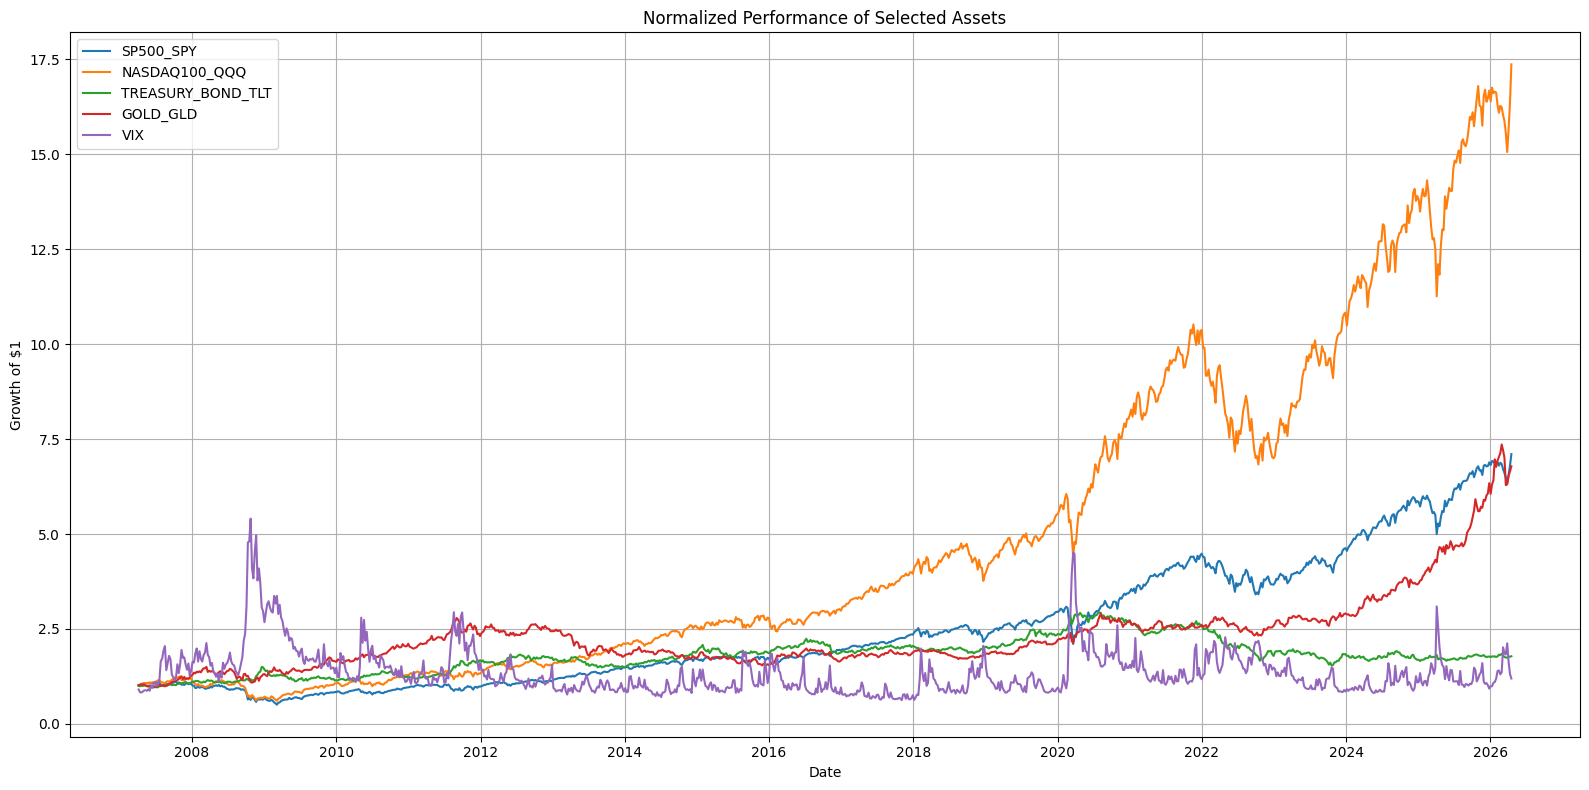

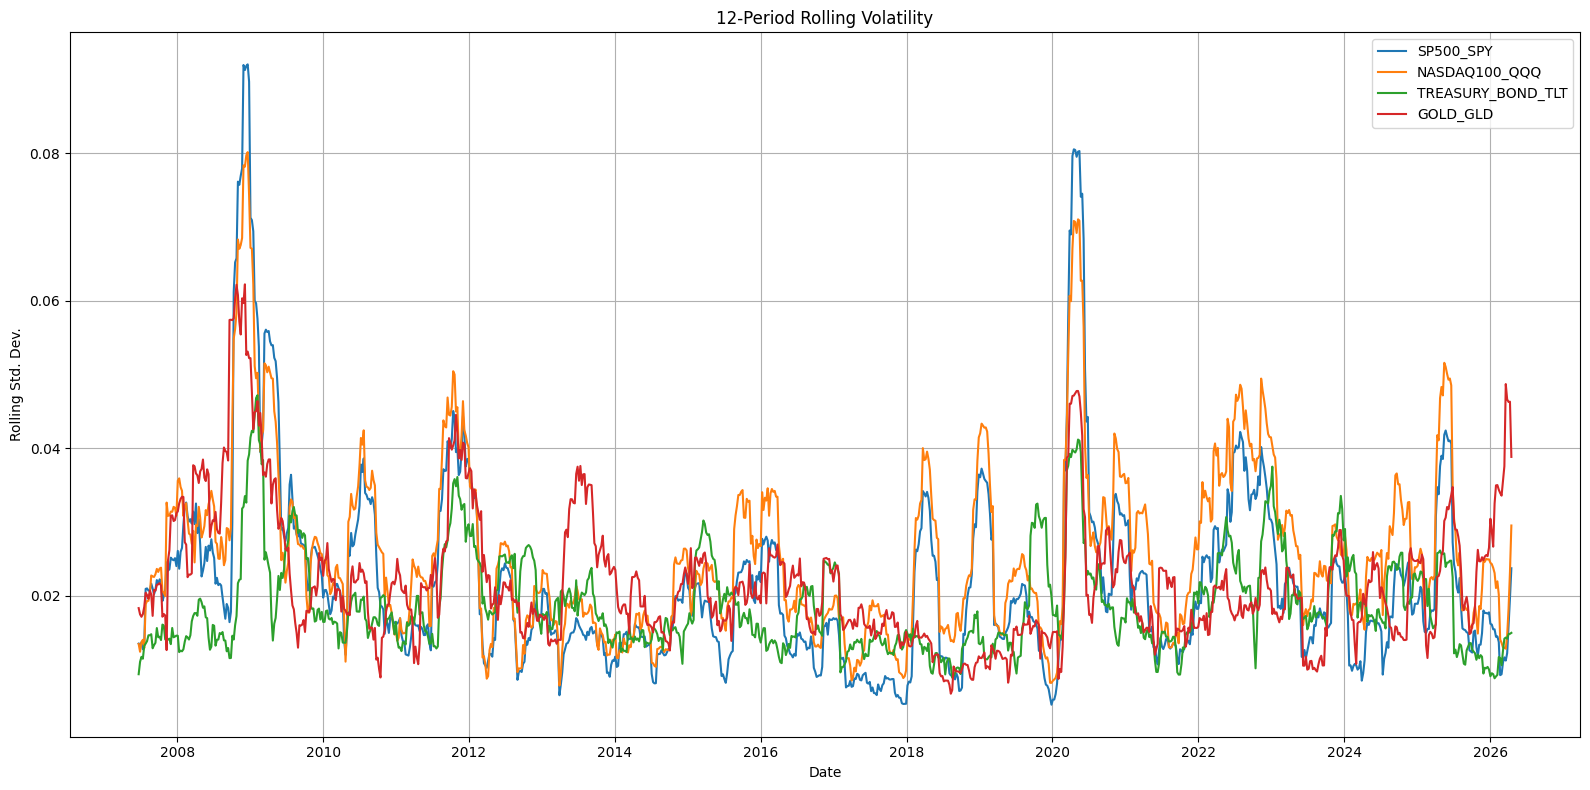

In [7]:
# Optional exploratory visuals for understanding asset behavior
# Not required for downstream modeling pipeline


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. copy original df
df = combine_unclean_df.copy()

# 2. convert to % returns
returns_df = df.pct_change()
returns_df = returns_df.replace([np.inf, -np.inf], np.nan)
returns_df = returns_df.dropna()

# 3. cleaner subset for visuals
selected_assets = [
    "SP500_SPY",
    "NASDAQ100_QQQ",
    "TREASURY_BOND_TLT",
    "GOLD_GLD",
    "ENERGY_XLE",
    "TECH_XLK",
    "UTILITIES_XLU",
    "FINANCIALS_XLF",
    "HEALTHCARE_XLV",
    "usd_index",
    "CRUDE_OIL_USO",
    "VIX"
]

returns_selected = returns_df[selected_assets]

# VISUAL 1: Average Return
avg_returns = returns_selected.mean().sort_values()

plt.figure(figsize=(10, 8))
avg_returns.plot(kind='barh')
plt.title("Average % Change by Asset")
plt.xlabel("Average % Change")
plt.ylabel("Asset")
plt.tight_layout()
plt.show()

# VISUAL 2: Volatility
volatility = returns_selected.std().sort_values()

plt.figure(figsize=(10, 8))
volatility.plot(kind='barh')
plt.title("Volatility (Std. Dev. of % Change) by Asset")
plt.xlabel("Standard Deviation of % Change")
plt.ylabel("Asset")
plt.tight_layout()
plt.show()

# VISUAL 3: Correlation Heatmap
corr_matrix = returns_selected.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, annot=False)
plt.title("Correlation Heatmap of Asset % Changes")
plt.tight_layout()
plt.show()

# VISUAL 4: Growth of $1
normalized_df = (1 + returns_selected).cumprod()

plt.figure(figsize=(16, 8))
for col in ["SP500_SPY", "NASDAQ100_QQQ", "TREASURY_BOND_TLT", "GOLD_GLD", "VIX"]:
    if col in normalized_df.columns:
        plt.plot(normalized_df.index, normalized_df[col], label=col)

plt.title("Normalized Performance of Selected Assets")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# VISUAL 5: Rolling Volatility
rolling_vol = returns_selected[["SP500_SPY", "NASDAQ100_QQQ", "TREASURY_BOND_TLT", "GOLD_GLD"]].rolling(12).std()

plt.figure(figsize=(16, 8))
for col in rolling_vol.columns:
    plt.plot(rolling_vol.index, rolling_vol[col], label=col)

plt.title("12-Period Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Rolling Std. Dev.")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=059a5e93-4459-411b-9a58-2a578fd7a892' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>